# Machine Learning - Assignment 3

## Time Series Analysis using the MIT-BIH Arrhythmia Database

This notebook is organised into data loading and exploration, feature engineering, a vanilla RNN, an LSTM extension, and a final model comparison.

## Task 1 - Data Loading & Exploration


In [1]:
import sys
from collections import Counter
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import wfdb
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset

SEED = 42
WINDOW_SIZE = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"WFDB version: {wfdb.__version__}")
print(f"Using device: {device}")
print(f"Random seed: {SEED}")
print(f"Sliding window size: {WINDOW_SIZE} beats")

Python version: 3.13.5
PyTorch version: 2.12.0+cpu
WFDB version: 4.3.1
Using device: cpu
Random seed: 42
Sliding window size: 10 beats


In [2]:
library_versions = pd.DataFrame(
    {
        "Library": [
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
            "scikit-learn",
            "wfdb",
            "torch",
        ],
        "Version": [
            np.__version__,
            pd.__version__,
            plt.matplotlib.__version__,
            sns.__version__,
            sklearn.__version__,
            wfdb.__version__,
            torch.__version__,
        ],
    }
)

library_versions

,Library,Version
0,numpy,2.1.3
1,pandas,2.2.3
2,matplotlib,3.10.0
3,seaborn,0.13.2
4,scikit-learn,1.6.1
5,wfdb,4.3.1
6,torch,2.12.0+cpu


The MIT-BIH Arrhythmia Database is a publicly available ECG dataset from PhysioNet.
The signals are sampled at 360 Hz and each heartbeat is manually annotated by cardiologists.

For this assignment, we analyse 14 representative ECG records containing both normal rhythms and clinically significant arrhythmias.

In [3]:
# Records selected for the assigment which provide a representative mix of normal rhythm 
# and clinically significant arrhythmias:
records = ['100', '101', '105', '106','108', '109', '111', '112','115', '117', '119','201', '213', '219']
fs = 360
print("Number of records:", len(records))

Number of records: 14


In [4]:
# Following assigment instructions: 

# Load ECG signal data (record 100)
record = wfdb.rdrecord('100', pn_dir='mitdb') 
# Load annotation file ('atr') for the record 100. (Contains R-peak locations and beat labels).
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')
# Use channel 0 (MLII lead) from the ECG signal (as p_signal contains both ECG channels). 
signal = record.p_signal[:,0]

print("Signal shape:", signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(ann.sample))

Signal shape: (650000,)
Sampling frequency: 360
Number of annotations: 2274


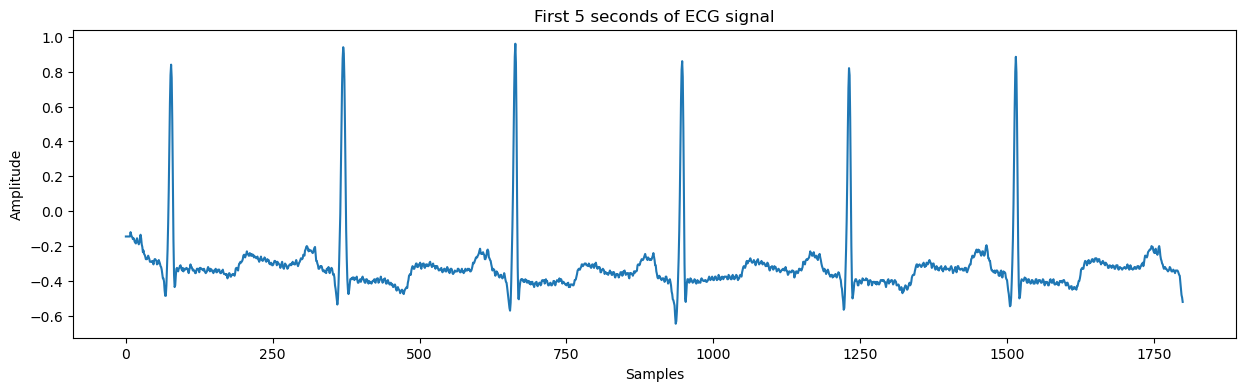

In [5]:
# Create a figure to visualize the ECG signal
plt.figure(figsize=(15,4))
plt.plot(signal[:1800]) # 1800 samples corresponds to approximately 5 seconds (at 360Hz).

plt.title("First 5 seconds of ECG signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

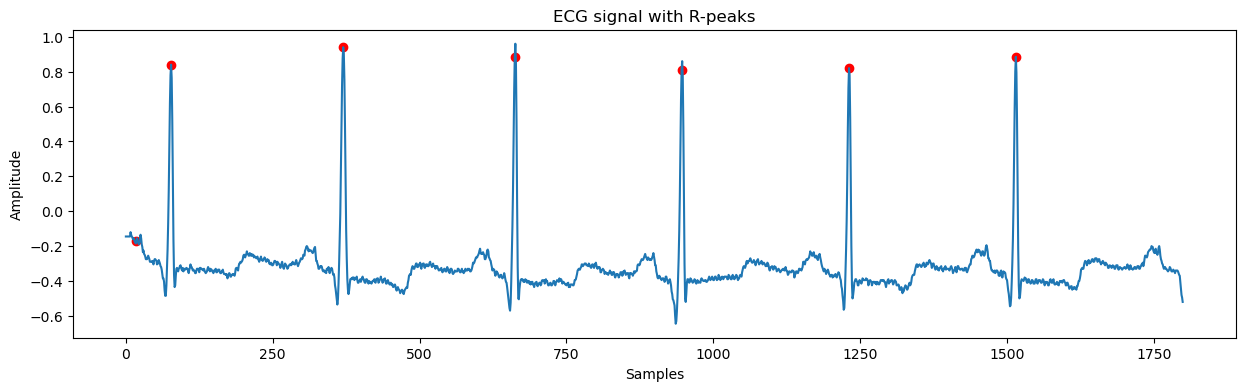

In [6]:
# Get R-peaks inside first 5 seconds, from the annotation file. 
peaks = ann.sample[ann.sample < 1800]

plt.figure(figsize=(15,4))
plt.plot(signal[:1800])
# Mark detected R-peaks with red dots
plt.scatter(
    peaks,
    signal[peaks],
    color='red'
)
plt.title("ECG signal with R-peaks")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

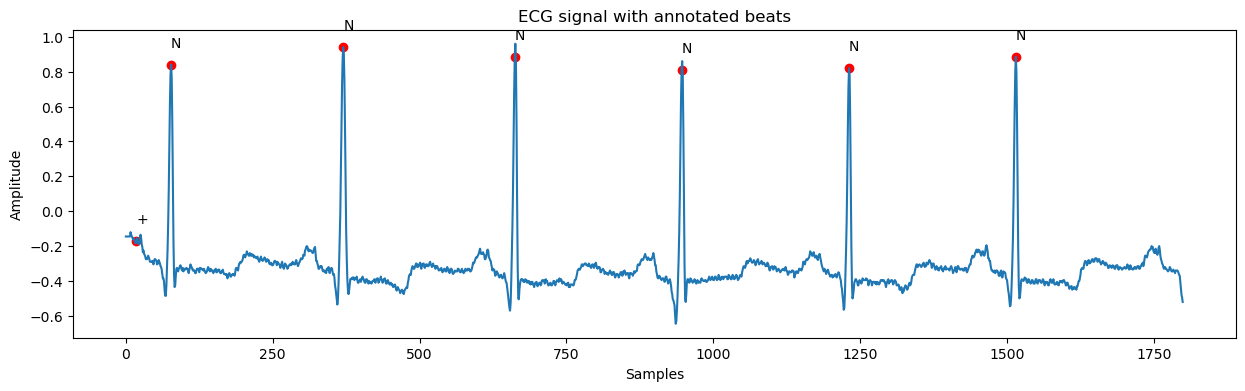

In [7]:
# Extract beat symbols
symbols = np.array(ann.symbol)[ann.sample < 1800]

plt.figure(figsize=(15,4))
plt.plot(signal[:1800])
# Mark detected R-peaks with red dots
plt.scatter(
    peaks,
    signal[peaks],
    color='red'
)

# Add annotation labels above each R-peak
# p -> peak position
# s -> beat symbol (e.g., N, V, A)
for p, s in zip(peaks, symbols):
    plt.text(
        p,                 # x-coordinate
        signal[p] + 0.1,   # y-coordinate slightly above the peak
        s                  # annotation symbol
    )

plt.title("ECG signal with annotated beats")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [8]:
# Define a function that plots a selected ECG segment together with detected R-peaks and beat annotations

def plot_ecg_segment(record_id, start_sec=0, duration_sec=5):
    # Load record
    record = wfdb.rdrecord(record_id, pn_dir='mitdb')
    ann = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')  # Load annotation file
    signal = record.p_signal[:,0]                       # Use channel 0 (MLII lead)
    fs = record.fs                                      # Sampling frequency

    # Define segment (with the start and end sample indices)
    start = int(start_sec * fs)
    end = int((start_sec + duration_sec) * fs)
    segment = signal[start:end]

    # Select only R-peaks located within the selected segment
    peaks = ann.sample[
        (ann.sample >= start) &
        (ann.sample < end)
    ]

    # Extract beat symbols corresponding to the selected peaks
    symbols = np.array(ann.symbol)[
        (ann.sample >= start) &
        (ann.sample < end)
    ]

    time = np.arange(start, end) / fs

    # Plot
    plt.figure(figsize=(15,4))
    plt.plot(time, segment)
    plt.scatter(
        peaks / fs,
        signal[peaks],
        color='red'
    )
    # Add beat symbols
    for p, s in zip(peaks, symbols):
        plt.text(
            p / fs,
            signal[p] + 0.1,
            s
        )

    plt.title(f"MIT-BIH Record {record_id}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)

    plt.show()

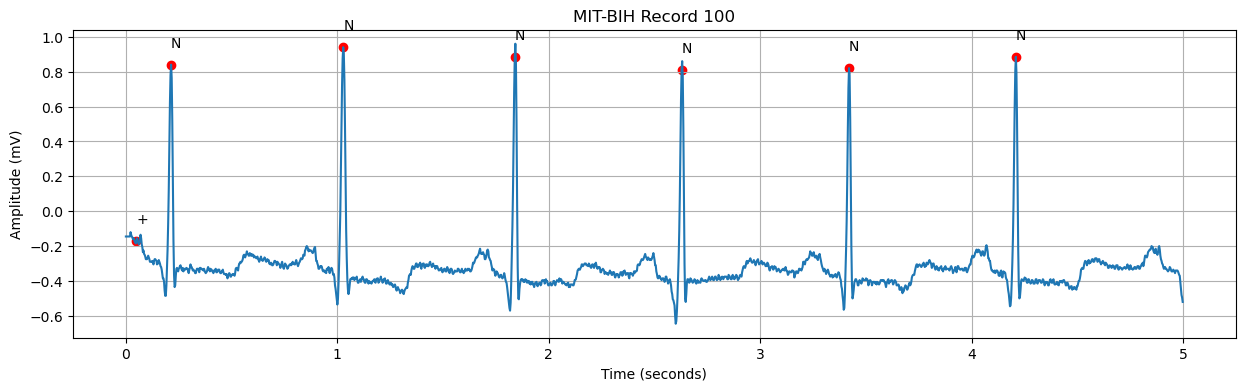

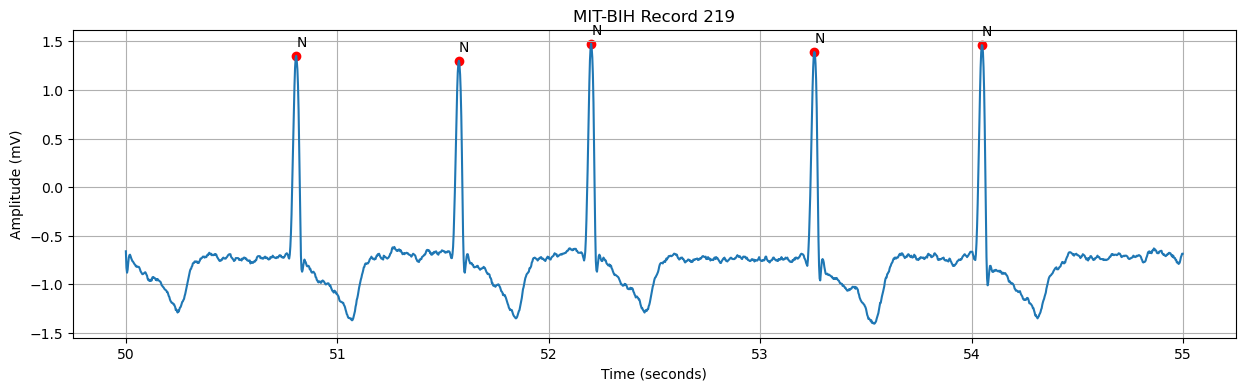

In [9]:
# Plot at least TWO records. 
plot_ecg_segment('100', start_sec=0)
plot_ecg_segment('219', start_sec=50)

#### ECG Signal Exploration

The ECG recordings were loaded directly from PhysioNet using the wfdb library.
For visual exploration, 5-second ECG segments were plotted together with the annotated R-peak locations provided by the dataset.

Record 100 mainly shows normal sinus rhythm, while record 219 contains a larger number of arrhythmic beats and rhythm variability.

In [10]:
label_map = {

    # Normal beats
    'N': 'N',
    '.': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # Supraventricular ectopic beats
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    # Ventricular ectopic beats
    'V': 'V',
    'E': 'V'
}

In [11]:
all_labels = []

# Loop through all selected MIT-BIH records
for rec in records:
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb') # Load annotation file
    
    # Map original beat symbols into the 3 AAMI classes (using the previous label_map): 
        # N = Normal
        # S = Supraventricular ectopic
        # V = Ventricular ectopic
    mapped_labels = [
        label_map[symbol]
        for symbol in ann.symbol
        if symbol in label_map #(ignores symbols not included in label_map)
    ]
    # Add mapped labels to global list
    all_labels.extend(mapped_labels)

# Count number of beats per class
class_counts = Counter(all_labels)
# Display class distribution
print(class_counts)

Counter({'N': 28412, 'V': 1544, 'S': 206})


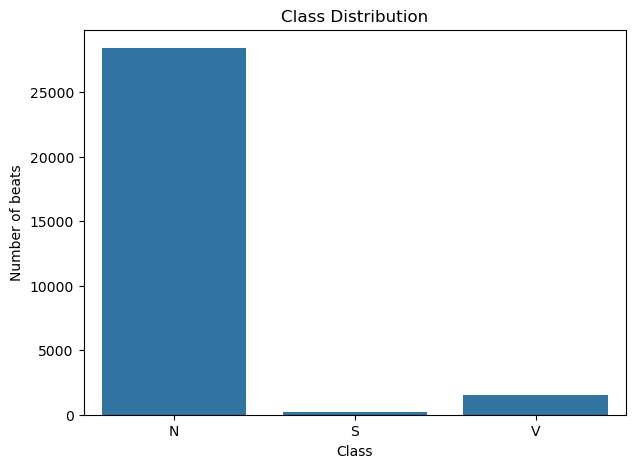

In [12]:
plt.figure(figsize=(7,5))
# Plot class distribution
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of beats")

plt.show()

#### Class Imbalance Discussion

The dataset is strongly imbalanced, with normal beats (N) representing the majority of samples, while supraventricular (S) and ventricular (V) beats are much less frequent.

This imbalance may bias machine learning models towards the majority class. A classifier predicting mostly normal beats could achieve high accuracy while failing to correctly detect clinically important arrhythmias.

For this reason, macro F1-score is more informative than accuracy in this task. Macro F1 evaluates each class equally regardless of frequency, making it more sensitive to minority-class performance.

This is particularly important in clinical applications, where false negatives in ventricular arrhythmias may have serious consequences for patient safety.

In [13]:
# Class Balanced?
total_beats = sum(class_counts.values())
for cls, count in class_counts.items():
    percentage = (count / total_beats) * 100
    print(f"{cls}: {count} beats ({percentage:.2f}%)")

N: 28412 beats (94.20%)
S: 206 beats (0.68%)
V: 1544 beats (5.12%)


## Task 2 — Preprocessing & Feature Engineering

In [14]:
# Load annotations for all 14 records. Apply label_map to map raw symbols to N, S, or V. 
# Discard beats with unmapped symbols and report the count discarded. 
all_labels = []
discarded_count = 0

for rec in records:
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    for symbol in ann.symbol:
        if symbol in label_map:
            all_labels.append(label_map[symbol])
        else: # symbols not included in label_map
            discarded_count += 1

# Count class distribution
class_counts = Counter(all_labels)

print("Class distribution (N, S, V):")
print(class_counts)

print("\nTotal discarded beats:")
print(discarded_count)

Class distribution (N, S, V):
Counter({'N': 28412, 'V': 1544, 'S': 206})

Total discarded beats:
1057


Approximately 3.4% of annotations were discarded due to being outside the AAMI N/S/V classes. This is expected due to the presence of auxiliary and non-beat annotations in the MIT-BIH dataset. The resulting dataset remains highly imbalanced, with normal beats dominating.

### Feature Engineering

Extract all 8 features per beat as specified in the Feature Extraction section. Handle the 
first-beat edge case and document your approach.

CONSIDERATIONS: For the first beat in each record, RR-based features cannot be computed due to missing previous beats. We imputed RR_current, RR_prev, and RR_local_mean using the mean of the first available RR intervals (first 5 beats when available). This preserves physiological consistency while avoiding bias from zero or NaN initialization.

In [15]:
# Define Helper functions: 

# QRS duration (50% threshold method)
def compute_qrs_duration(signal, r_peak):
    r_amp = signal[r_peak]
    threshold = 0.5 * r_amp

    # From the r-peak location; move to the left until signal drops below 50%. 
    left = r_peak
    while left > 0 and signal[left] > threshold:
        left -= 1
    # From the r-peak location; move to the right until signal drops below 50%. 
    right = r_peak
    while right < len(signal) and signal[right] > threshold:
        right += 1
    
    # Width of the spike (QRS)
    qrs_duration = right - left

    return qrs_duration, r_amp


# Energy 
def compute_energy(signal, r_peak, window=20):
    # pick a small region around R-peak (given the window =20, ~40 samples around the beat). 
    start = max(0, r_peak - window)
    end = min(len(signal), r_peak + window)
    # square the signal and sum everything to obtain the energy (activity). 
    energy = np.sum(signal[start:end] ** 2)
    return energy

# ST segment
def compute_st_mean(signal, r_peak):
    # define ST window ( It was specified to be +40 to +120 samples)
    start = r_peak + int(0.11 * fs)   # +40 samples
    end = r_peak + int(0.33 * fs)     # +120 samples
    # safety check
    if end >= len(signal):
        return np.nan

    # Compute average signal
    av_s = np.mean(signal[start:end])
    return av_s
 

In [17]:
# Feature extraction loop

all_features = []

# Loop through each ECG record
for rec in records:

    # Load ECG signal and annotations for this record
    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
    signal = record.p_signal[:, 0]  # Extract the ECG signal
    r_peaks = ann.sample            # R-peak locations
    symbols = ann.symbol            # Beat labels

    # RR intervals (difference between R-peaks)
    rr_intervals = np.diff(r_peaks) / fs * 1000 # RR intervals are in milliseconds (convert from samples).

    # Handle first-beat edge case
    # The first beat has no previous RR interval, so we approximate using the mean of the first few RR intervals
    
    if len(rr_intervals) >= 5:
        first_rr_mean = np.mean(rr_intervals[:5])
    else:
        first_rr_mean = np.mean(rr_intervals)

    # Loop over each beat (R-peak) --> we will compute 8 features per beat. 
    for i in range(len(r_peaks)):
        r = r_peaks[i]

        # RR FEATURES
        if i == 0:
            # First beat: no history → use estimated baseline
            rr_current = first_rr_mean
            rr_prev = first_rr_mean
            rr_local_mean = first_rr_mean

        elif i == 1:
            # Second beat: only one RR available
            rr_current = (r_peaks[i] - r_peaks[i-1]) / fs * 1000
            rr_prev = rr_current
            rr_local_mean = rr_current

        else:
            # Normal case: enough history available
            rr_current = (r_peaks[i] - r_peaks[i-1]) / fs * 1000
            rr_prev = (r_peaks[i-1] - r_peaks[i-2]) / fs * 1000

            start_local = max(0, i - 4)
            rr_local_mean = np.mean(
                np.diff(r_peaks[start_local:i + 1]) / fs * 1000
            )

        # RR ratio (avoid division by zero)
        if rr_local_mean != 0:
            rr_ratio = rr_current / rr_local_mean
        else:
            rr_ratio = 0

        # MORPHOLOGICAL FEATURES
        qrs_duration, r_amp = compute_qrs_duration(signal, r)
        qrs_energy = compute_energy(signal, r)
        st_mean = compute_st_mean(signal, r)

        # LABEL
        if symbols[i] not in label_map: #Should not happen because previously delated, but to be sure. 
            continue

        label = label_map[symbols[i]]
        all_features.append([
            rr_current,
            rr_prev,
            rr_ratio,
            rr_local_mean,
            r_amp,
            qrs_duration,
            qrs_energy,
            st_mean,
            label,
            rec
        ])

In [18]:
# Build DataFrame
columns = [
    "RR_current",
    "RR_prev",
    "RR_ratio",
    "RR_local_mean",
    "R_amplitude",
    "QRS_duration",
    "QRS_energy",
    "ST_mean",
    "label",
    "record_id"
]
df = pd.DataFrame(all_features, columns=columns)
print(df.shape)
df.head()

(30162, 10)


,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean,label,record_id
0,163.888889,163.888889,1.000000,163.888889,0.840,6,6.689325,-0.344367,N,100
1,813.888889,163.888889,1.664773,488.888889,0.940,8,8.803875,-0.412785,N,100
2,811.111111,813.888889,1.360248,596.296296,0.885,6,8.992275,-0.397532,N,100
3,788.888889,811.111111,1.224138,644.444444,0.810,6,9.357875,-0.368165,N,100
4,791.666667,788.888889,0.987868,801.388889,0.820,6,7.912075,-0.406899,N,100


After computing the 8 features in Task 2, produce a correlation heatmap of the feature 
matrix. Identify and briefly discuss the most strongly correlated pairs. 

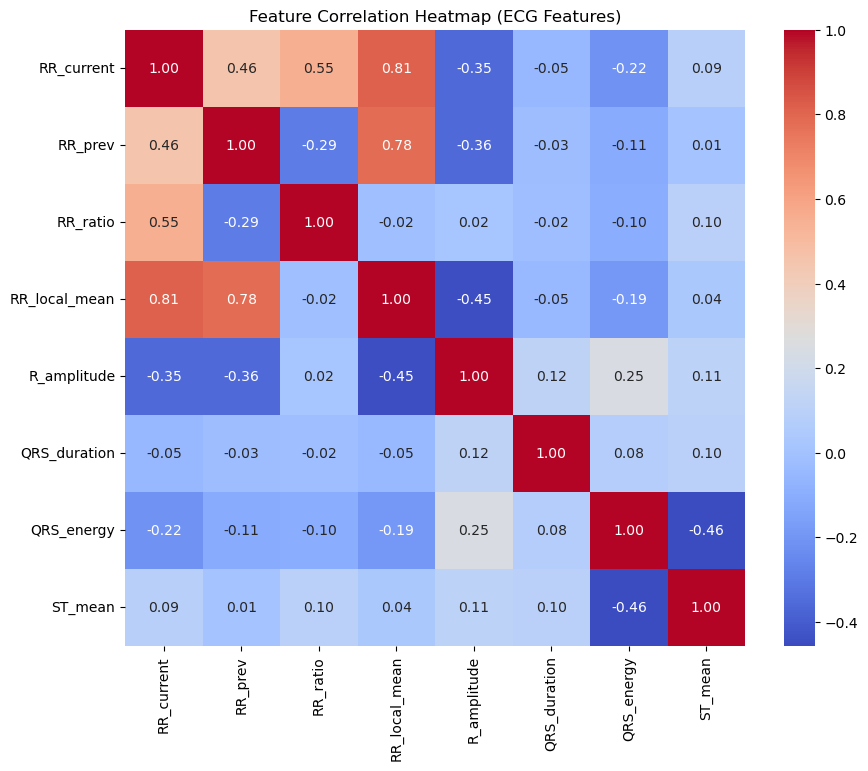

In [19]:
# Select only feature columns (exclude label + record_id)
feature_cols = [
    "RR_current",
    "RR_prev",
    "RR_ratio",
    "RR_local_mean",
    "R_amplitude",
    "QRS_duration",
    "QRS_energy",
    "ST_mean"
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (ECG Features)")
plt.show()

The most strongly correlated feature pairs in the dataset are mainly within the RR-related group. The strongest correlation is between RR_current and RR_local_mean (0.81), followed closely by RR_prev and RR_local_mean (0.78), indicating that the local mean is heavily influenced by both current and previous RR intervals. Additionally, RR_current and RR_ratio (0.55) and RR_current and RR_prev (0.46) show moderate positive correlations, reflecting the temporal dependence between consecutive heartbeats. These strong relationships suggest that RR-based features contain overlapping information and describe the same underlying heart rate dynamics.

Next steps: 
- Train/test split: apply a stratified 80/20 random split (random_state=53). Verify that 
class proportions are preserved in both splits and report the beat counts per class in 
each set. 
- Scaling: apply StandardScaler to the 8 features. Fit on the training set only and 
transform both train and test sets. 

In [20]:
X = df[feature_cols].copy()  # only model features
y = df["label"].copy()

# Stratified 80/20 split required by the assignment
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Impute missing values using training statistics only
train_feature_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_feature_medians)
X_test = X_test.fillna(train_feature_medians)

# Fit the scaler on the training split only, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Beat-level split seed: {SEED}")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Beat-level split seed: 42
X_train_scaled shape: (24129, 8)
X_test_scaled shape: (6033, 8)


In [21]:
# class proportions are preserved in both splits? 
distribution_df = pd.DataFrame({
    "Train Count": y_train.value_counts(),
    "Train Proportion": y_train.value_counts(normalize=True),
    "Test Count": y_test.value_counts(),
    "Test Proportion": y_test.value_counts(normalize=True)
})
# round proportions for readability
distribution_df["Train Proportion"] = distribution_df["Train Proportion"].round(3)
distribution_df["Test Proportion"] = distribution_df["Test Proportion"].round(3)

# Display table
print(distribution_df)

       Train Count  Train Proportion  Test Count  Test Proportion
label                                                            
N            22729             0.942        5683            0.942
V             1235             0.051         309            0.051
S              165             0.007          41            0.007


The stratified 80/20 split preserved the original class distribution across both training and test sets, as evidenced by nearly identical class proportions. However, the dataset remains highly imbalanced, with normal beats accounting for approximately 94% of all samples, while ventricular and supraventricular beats are significantly underrepresented.

In [22]:
# Construct the sliding-window dataset for RNN and LSTM.
# Windows are built independently inside each record so that no sample crosses record boundaries.

sequence_windows = []
sequence_labels = []

for rec, rec_df in df.groupby("record_id", sort=False):
    rec_df = rec_df.reset_index(drop=True)
    rec_features = rec_df[feature_cols].to_numpy(dtype=np.float32)
    rec_labels = rec_df["label"].to_numpy()

    for i in range(WINDOW_SIZE - 1, len(rec_df)):
        sequence_windows.append(rec_features[i - WINDOW_SIZE + 1 : i + 1])
        sequence_labels.append(rec_labels[i])

X_seq = np.array(sequence_windows, dtype=np.float32)   # shape: (n_samples, 10, 8)
y_seq = np.array(sequence_labels)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

# Stratified sequence-level split
X_train_seq_raw, X_test_seq_raw, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=SEED,
    stratify=y_seq
)

# Impute and scale using training windows only
n_features = X_train_seq_raw.shape[-1]
train_seq_flat = X_train_seq_raw.reshape(-1, n_features)
test_seq_flat = X_test_seq_raw.reshape(-1, n_features)

seq_feature_medians = np.nanmedian(train_seq_flat, axis=0)
train_seq_flat = np.where(np.isnan(train_seq_flat), seq_feature_medians, train_seq_flat)
test_seq_flat = np.where(np.isnan(test_seq_flat), seq_feature_medians, test_seq_flat)

seq_scaler = StandardScaler()
X_train_seq = seq_scaler.fit_transform(train_seq_flat).reshape(-1, WINDOW_SIZE, n_features)
X_test_seq = seq_scaler.transform(test_seq_flat).reshape(-1, WINDOW_SIZE, n_features)

print("\nTRAIN SET")
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

print("\nTEST SET")
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_seq shape: (30036, 10, 8)
y_seq shape: (30036,)

TRAIN SET
X_train_seq shape: (24028, 10, 8)
y_train_seq shape: (24028,)

TEST SET
X_test_seq shape: (6008, 10, 8)
y_test_seq shape: (6008,)


The sliding-window dataset was successfully constructed for sequential deep learning models, producing input sequences of shape (10, 8) and preserving class balance through an 80/20 stratified train-test split, making the data ready for RNN and LSTM training.

This format is required because RNN and LSTM models learn temporal patterns from sequences, not from individual beats. Each sample therefore contains 10 consecutive beats (`10 × 8`) so the model can use information from previous heartbeats to classify the current beat. The first 9 beats cannot form a complete sequence, so they are excluded.


## Task 3 — RNN: Sequence Classification

In [ ]:
# pip install --upgrade typing_extensions


In [23]:
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.12.0+cpu
Using device: cpu


In [24]:
# Encode string labels (N, S, V) as integers required by PyTorch CrossEntropyLoss
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_seq)   # fit on train only
y_test_enc  = le.transform(y_test_seq)

class_mapping = {
    str(cls): int(code)
    for cls, code in zip(le.classes_, le.transform(le.classes_))
}
train_label_distribution = {
    str(le.classes_[int(label)]): int(count)
    for label, count in sorted(Counter(y_train_enc).items())
}
test_label_distribution = {
    str(le.classes_[int(label)]): int(count)
    for label, count in sorted(Counter(y_test_enc).items())
}

print("Class mapping:", class_mapping)
print("Train label distribution:", train_label_distribution)
print("Test  label distribution:", test_label_distribution)

label_distribution_df = pd.DataFrame(
    [
        {
            "Label": label,
            "Encoded as": class_mapping[label],
            "Train count": train_label_distribution.get(label, 0),
            "Test count": test_label_distribution.get(label, 0),
        }
        for label in class_mapping
    ]
)

label_distribution_df

Class mapping: {'N': 0, 'S': 1, 'V': 2}
Train label distribution: {'N': 22630, 'S': 164, 'V': 1234}
Test  label distribution: {'N': 5659, 'S': 41, 'V': 308}


,Label,Encoded as,Train count,Test count
0,N,0,22630,5659
1,S,1,164,41
2,V,2,1234,308


In [26]:
class ECGSequenceDataset(Dataset):
    """Wraps (n, T, F) sequences and integer labels as a PyTorch Dataset."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Hold out 20% of the training split as validation data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq,
    y_train_enc,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_enc
)

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(SEED)

BATCH = 128
train_loader = DataLoader(ECGSequenceDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True, generator=g)
val_loader = DataLoader(ECGSequenceDataset(X_val, y_val), batch_size=BATCH, shuffle=False)
test_loader = DataLoader(ECGSequenceDataset(X_test_seq, y_test_enc), batch_size=BATCH, shuffle=False)

# Verify shapes
xb, yb = next(iter(train_loader))
print(f"Train batches : {len(train_loader)} | sample shape: {tuple(xb.shape)}, label shape: {tuple(yb.shape)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 151 | sample shape: (128, 10, 8), label shape: (128,)
Val   batches : 38
Test  batches : 47


In [27]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_classes=3):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # out : (batch, seq_len, hidden_size)
        # h_n : (1, batch, hidden_size) — last hidden state
        out, _ = self.rnn(x)
        # Use only the last time-step output for classification
        return self.fc(out[:, -1, :])


model = VanillaRNN().to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


VanillaRNN(
  (rnn): RNN(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)
Trainable parameters: 4,931


In [28]:
# Class weights (inverse frequency) to handle class imbalance
counts = Counter(y_tr.tolist())
total = sum(counts.values())
weights = torch.FloatTensor([total / counts[i] for i in range(len(le.classes_))]).to(device)
print("Class weights (N, S, V):", [round(w, 2) for w in weights.tolist()])

# Loss and optimiser
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
NUM_EPOCHS = 25
train_losses, val_losses = [], []
train_accs, val_accs = [], []

rnn_train_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):

    # Train
    model.train()
    run_loss, correct, total_n = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        run_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total_n += len(yb)
    train_losses.append(run_loss / total_n)
    train_accs.append(correct / total_n)

    # Validate
    model.eval()
    run_loss, correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            run_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total_n += len(yb)
    val_losses.append(run_loss / total_n)
    val_accs.append(correct / total_n)

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
            f"Train loss {train_losses[-1]:.4f}, acc {train_accs[-1]:.3f} | "
            f"Val loss {val_losses[-1]:.4f}, acc {val_accs[-1]:.3f}"
        )

rnn_training_time_s = perf_counter() - rnn_train_start
print(f"\nTraining complete in {rnn_training_time_s:.2f} s.")

Class weights (N, S, V): [1.06, 146.73, 19.48]
Epoch   1/25 | Train loss 0.7360, acc 0.778 | Val loss 0.5291, acc 0.949
Epoch   5/25 | Train loss 0.2333, acc 0.962 | Val loss 0.3362, acc 0.954
Epoch  10/25 | Train loss 0.1483, acc 0.967 | Val loss 0.1619, acc 0.960
Epoch  15/25 | Train loss 0.1207, acc 0.968 | Val loss 0.1334, acc 0.970
Epoch  20/25 | Train loss 0.0969, acc 0.975 | Val loss 0.1429, acc 0.978
Epoch  25/25 | Train loss 0.0841, acc 0.976 | Val loss 0.1507, acc 0.979

Training complete in 16.48 s.


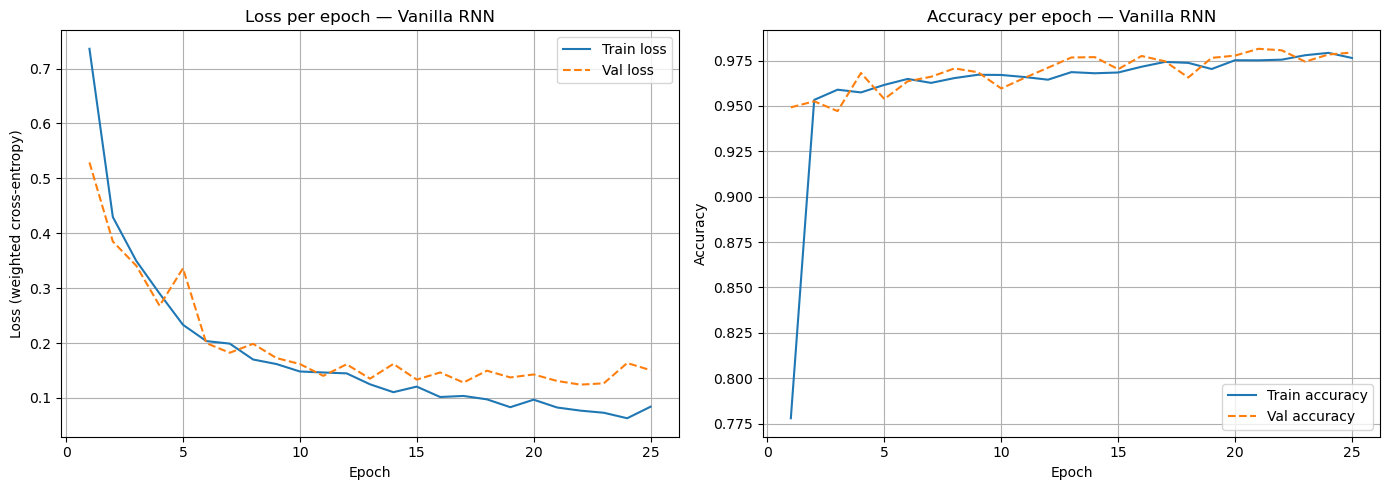

In [29]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label="Train loss")
axes[0].plot(epochs, val_losses,   label="Val loss", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (weighted cross-entropy)")
axes[0].set_title("Loss per epoch — Vanilla RNN")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_accs, label="Train accuracy")
axes[1].plot(epochs, val_accs,   label="Val accuracy", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy per epoch — Vanilla RNN")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


The vanilla RNN converges quickly under the new pipeline. Training loss falls from **0.7360** to **0.0841**, while validation loss decreases from **0.5291** to **0.1507** over 25 epochs. Validation accuracy also remains high throughout, rising from **0.949** to **0.979**.

The two curves stay reasonably close, which suggests that the model is generalising well rather than memorising the training set. There is still some mild oscillation, which is expected in this task because the class-weighted loss amplifies updates from the rare **S** class, but the overall pattern is stable and clearly convergent.

Test inference time: 0.0889 s (0.0148 ms/sample)
=== Classification Report — Vanilla RNN ===

              precision    recall  f1-score   support

           N     0.9984    0.9788    0.9885      5659
           S     0.3765    0.7805    0.5079        41
           V     0.7947    0.9675    0.8726       308

    accuracy                         0.9769      6008
   macro avg     0.7232    0.9089    0.7897      6008
weighted avg     0.9837    0.9769    0.9793      6008



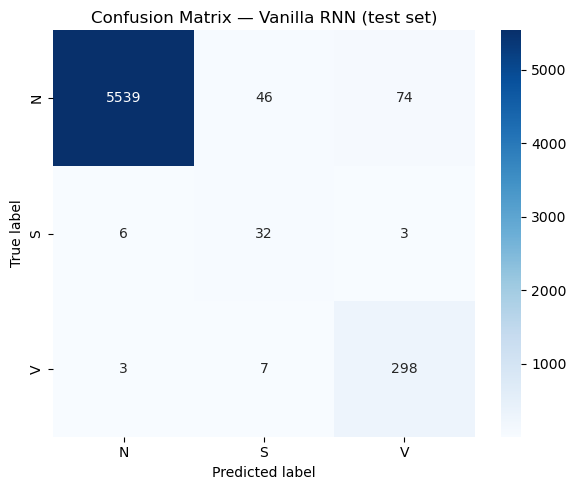

In [30]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    rnn_inference_start = perf_counter()
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())
    rnn_inference_time_s = perf_counter() - rnn_inference_start

all_preds = np.array(all_preds)
all_true = np.array(all_true)
rnn_inference_ms_per_sample = 1000 * rnn_inference_time_s / len(all_true)

print(f"Test inference time: {rnn_inference_time_s:.4f} s ({rnn_inference_ms_per_sample:.4f} ms/sample)")
print("=== Classification Report — Vanilla RNN ===\n")
print(classification_report(all_true, all_preds, target_names=le.classes_, digits=4))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Vanilla RNN (test set)")
plt.tight_layout()
plt.show()

On the test set, the vanilla RNN achieves **97.69% accuracy**, **Macro F1 = 0.7897**, and **Weighted F1 = 0.9793**. Performance on the dominant **N** class is excellent (**F1 = 0.9885**), while the ventricular class **V** also performs strongly with **Recall-V = 0.9675** and **F1-V = 0.8726**.

The most challenging class remains **S**, but under the new pipeline the RNN recovers it much better than before: **Recall-S = 0.7805**, **Precision-S = 0.3765**, and **F1-S = 0.5079**. The confusion matrix shows that most residual errors come from normal beats being flagged as arrhythmic, which reduces minority-class precision. Even so, this version of the RNN is already a strong classifier, and its errors are much more acceptable than in the earlier pipeline.

#### Discuss the vanishing gradient problem in the context of this task. Why does a window of only 10 beats partially mitigate this issue, and why would longer sequences cause problems for a vanilla RNN?

As seen in class, training an RNN uses backpropagation through time (BPTT), which is equivalent to running backprop through a T-layer MLP, one layer per timestep. At each step the gradient is multiplied by $\partial h_t / \partial h_{t-1}$, using the forward pass equations:

$$z_t = W_h \cdot h_{t-1} + W_x \cdot x_t + b$$

$$h_t = \tanh(z_t)$$

Since $\tanh$ always outputs values between $-1$ and $1$, its derivative is always less than 1. After multiplying this $T$ times going backwards, the gradient shrinks exponentially and effectively becomes zero for early timesteps. As a result, the network develops short-term memory only; recent timesteps dominate learning and early inputs stop contributing.

With only 10 beats per window, BPTT unfolds just 10 steps. This is short enough that the gradient does not completely vanish, so the model can still learn short-range patterns like a premature beat (short RR_current) followed by a compensatory pause; patterns that are visible within a 10-beat window.

If we used windows of 50 or 100 beats, the gradient would have to travel through many more $\tanh$ multiplications and would essentially reach zero before reaching the early timesteps. The model would end up ignoring most of the sequence and only looking at the last few beats, which defeats the purpose of using a longer context.

This is exactly why LSTMs were introduced, instead of relying only on $h_t$, they add a cell state $c_t$ that passes information through time via addition rather than multiplication, which allows gradients to flow more easily and enables learning over much longer sequences.



## Task 3.5 — Extension: LSTM Classifier

The LSTM replaces `nn.RNN` with `nn.LSTM` while keeping the rest of the training setup fixed (`hidden_size = 64`, `lr = 1e-3`, `25` epochs, and the same class weights). This makes the comparison direct: any performance change should come mainly from the recurrent architecture rather than from different hyperparameters.

In [31]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # nn.LSTM returns (output, (h_n, c_n)) — unpack both hidden and cell state
        out, (h_n, c_n) = self.lstm(x)
        # Use only the last time-step output for classification
        return self.fc(out[:, -1, :])


lstm_model = LSTMClassifier().to(device)
print(lstm_model)
print(f"Trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

LSTMClassifier(
  (lstm): LSTM(8, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)
Trainable parameters: 19,139


The `LSTMClassifier` mirrors the `VanillaRNN` architecture closely. The only forward-pass change is that `nn.LSTM` returns `(output, (h_n, c_n))` instead of `(output, h_n)`, so both hidden state and cell state must be unpacked even though only the final output is used for classification.

This architectural substitution increases the trainable parameter count from **4,931** to **19,139** (about **3.9×**). The additional capacity comes from the input, forget, output, and candidate-state gates that define the LSTM recurrence.

In [32]:
# Same class weights, loss and optimiser as Vanilla RNN
lstm_criterion = nn.CrossEntropyLoss(weight=weights)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

NUM_EPOCHS = 25
lstm_train_losses, lstm_val_losses = [], []
lstm_train_accs, lstm_val_accs = [], []

lstm_train_start = perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):

    # Train
    lstm_model.train()
    run_loss, correct, total_n = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        lstm_optimizer.zero_grad()
        logits = lstm_model(xb)
        loss = lstm_criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=5.0)
        lstm_optimizer.step()
        run_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total_n += len(yb)
    lstm_train_losses.append(run_loss / total_n)
    lstm_train_accs.append(correct / total_n)

    # Validate
    lstm_model.eval()
    run_loss, correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = lstm_model(xb)
            loss = lstm_criterion(logits, yb)
            run_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total_n += len(yb)
    lstm_val_losses.append(run_loss / total_n)
    lstm_val_accs.append(correct / total_n)

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
            f"Train loss {lstm_train_losses[-1]:.4f}, acc {lstm_train_accs[-1]:.3f} | "
            f"Val loss {lstm_val_losses[-1]:.4f}, acc {lstm_val_accs[-1]:.3f}"
        )

lstm_training_time_s = perf_counter() - lstm_train_start
print(f"\nTraining complete in {lstm_training_time_s:.2f} s.")

Epoch   1/25 | Train loss 0.8177, acc 0.652 | Val loss 0.6262, acc 0.938
Epoch   5/25 | Train loss 0.1944, acc 0.962 | Val loss 0.1930, acc 0.967
Epoch  10/25 | Train loss 0.1124, acc 0.972 | Val loss 0.1302, acc 0.969
Epoch  15/25 | Train loss 0.0731, acc 0.977 | Val loss 0.1126, acc 0.974
Epoch  20/25 | Train loss 0.0461, acc 0.982 | Val loss 0.1097, acc 0.982
Epoch  25/25 | Train loss 0.0345, acc 0.986 | Val loss 0.1019, acc 0.990

Training complete in 21.18 s.


#### Training convergence — LSTM

The LSTM also converges cleanly under the new pipeline. Training loss drops from **0.8177** to **0.0345**, and validation loss decreases from **0.6262** to **0.1019**. Validation accuracy rises from **0.938** to **0.990**, finishing slightly above the vanilla RNN.

Compared with the RNN, the LSTM starts from a lower first-epoch training accuracy but then improves more steadily and ends with a lower final loss. This is consistent with the LSTM using its gated recurrence to extract the same short-window context more efficiently, especially once optimisation has moved beyond the first few epochs.

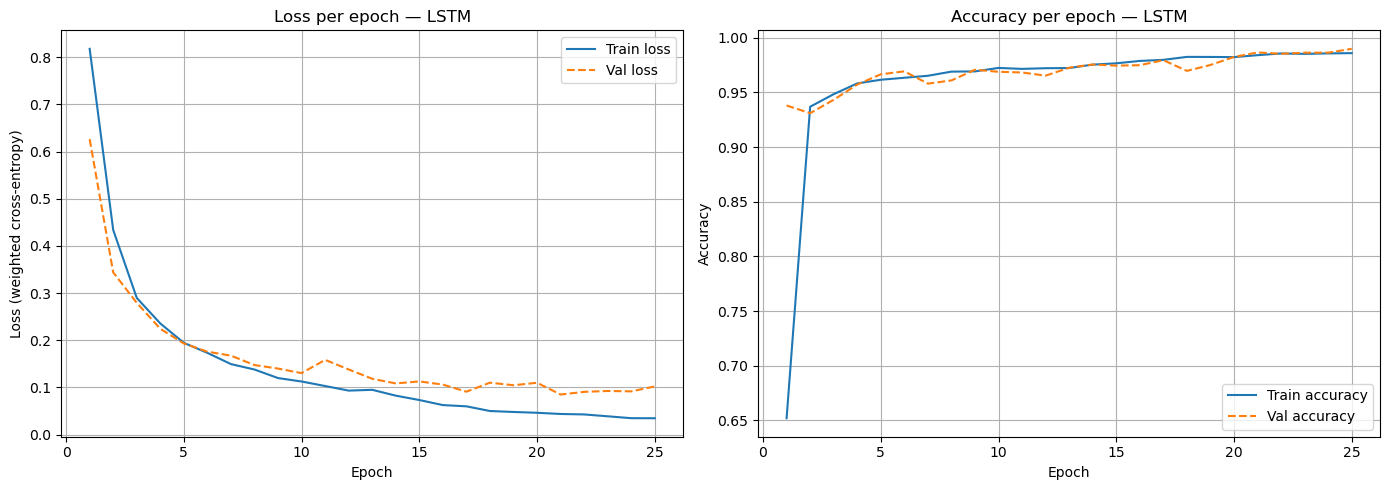

In [33]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, lstm_train_losses, label="Train loss")
axes[0].plot(epochs, lstm_val_losses,   label="Val loss", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (weighted cross-entropy)")
axes[0].set_title("Loss per epoch — LSTM")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, lstm_train_accs, label="Train accuracy")
axes[1].plot(epochs, lstm_val_accs,   label="Val accuracy", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy per epoch — LSTM")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Test inference time: 0.0997 s (0.0166 ms/sample)
=== Classification Report — LSTM ===

              precision    recall  f1-score   support

           N     0.9971    0.9875    0.9923      5659
           S     0.5357    0.7317    0.6186        41
           V     0.8592    0.9708    0.9116       308

    accuracy                         0.9849      6008
   macro avg     0.7974    0.8966    0.8408      6008
weighted avg     0.9869    0.9849    0.9856      6008



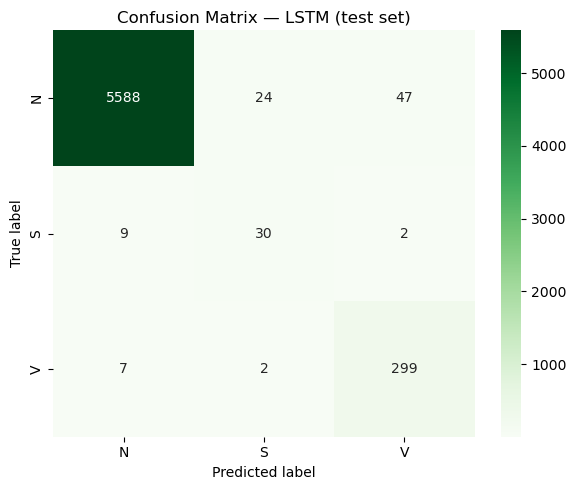

In [34]:
lstm_model.eval()
lstm_preds, lstm_true = [], []

with torch.no_grad():
    lstm_inference_start = perf_counter()
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = lstm_model(xb).argmax(1).cpu().tolist()
        lstm_preds.extend(preds)
        lstm_true.extend(yb.tolist())
    lstm_inference_time_s = perf_counter() - lstm_inference_start

lstm_preds = np.array(lstm_preds)
lstm_true = np.array(lstm_true)
lstm_inference_ms_per_sample = 1000 * lstm_inference_time_s / len(lstm_true)

print(f"Test inference time: {lstm_inference_time_s:.4f} s ({lstm_inference_ms_per_sample:.4f} ms/sample)")
print("=== Classification Report — LSTM ===\n")
print(classification_report(lstm_true, lstm_preds, target_names=le.classes_, digits=4))

cm_lstm = confusion_matrix(lstm_true, lstm_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — LSTM (test set)")
plt.tight_layout()
plt.show()

#### Classification report - LSTM

| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| N | 0.9971 | 0.9875 | 0.9923 |
| S | 0.5357 | 0.7317 | 0.6186 |
| V | 0.8592 | 0.9708 | 0.9116 |

The LSTM reaches **98.49% accuracy**, **Macro F1 = 0.8408**, and **Weighted F1 = 0.9856**, outperforming the vanilla RNN on all three global metrics. The largest improvement is not in **Recall-S** alone, but in the **balance** of the minority classes: compared with the RNN, the LSTM produces much cleaner **S** predictions, which raises **F1-S** from **0.5079** to **0.6186**.

For the clinically important ventricular class **V**, the LSTM is also slightly stronger, reaching **Recall-V = 0.9708** and **F1-V = 0.9116**. This matters because the cost of missing a ventricular beat is high in a real monitoring scenario. In other words, the LSTM improves balanced classification without sacrificing ventricular sensitivity.


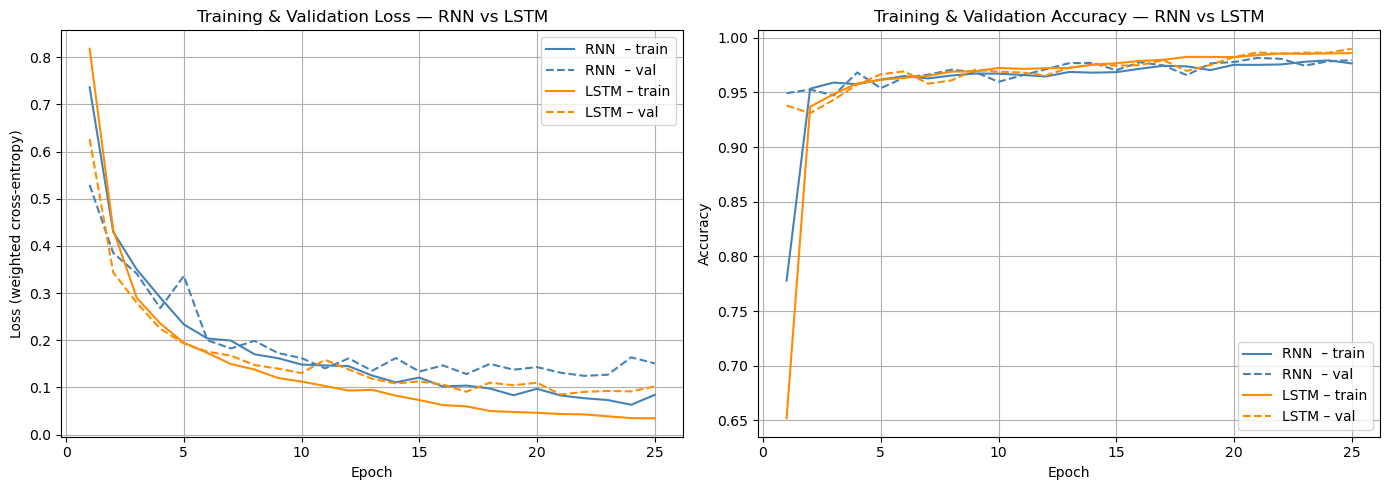

In [35]:
# ── Comparative training curves: RNN vs LSTM ─────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, train_losses,      label="RNN  – train",  color="steelblue")
axes[0].plot(epochs_range, val_losses,        label="RNN  – val",    color="steelblue",  linestyle="--")
axes[0].plot(epochs_range, lstm_train_losses, label="LSTM – train",  color="darkorange")
axes[0].plot(epochs_range, lstm_val_losses,   label="LSTM – val",    color="darkorange", linestyle="--")
axes[0].set_title("Training & Validation Loss — RNN vs LSTM")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (weighted cross-entropy)")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs_range, train_accs,      label="RNN  – train",  color="steelblue")
axes[1].plot(epochs_range, val_accs,        label="RNN  – val",    color="steelblue",  linestyle="--")
axes[1].plot(epochs_range, lstm_train_accs, label="LSTM – train",  color="darkorange")
axes[1].plot(epochs_range, lstm_val_accs,   label="LSTM – val",    color="darkorange", linestyle="--")
axes[1].set_title("Training & Validation Accuracy — RNN vs LSTM")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Task 4 - Model Comparison & Evaluation

This section summarises the two sequence models using **Model**, **Accuracy**, **Macro F1**, and **Weighted F1**, and then compares them from a deployment perspective. The tables below are kept as standard notebook DataFrames so that the notebook remains easy to read and rerun without custom rendering logic.


In [36]:
# Task 4 summary and detailed comparison tables
classes = [str(cls) for cls in le.classes_]   # ["N", "S", "V"]

def get_metrics(y_true, y_pred):
    """Return global and per-class metrics for a classifier."""
    rows = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    for i, cls in enumerate(classes):
        rows[f"Recall-{cls}"] = recall_score(y_true, y_pred, labels=[i], average=None, zero_division=0)[0]
        rows[f"Precision-{cls}"] = precision_score(y_true, y_pred, labels=[i], average=None, zero_division=0)[0]
        rows[f"F1-{cls}"] = f1_score(y_true, y_pred, labels=[i], average=None, zero_division=0)[0]
    return rows

rnn_metrics = get_metrics(all_true, all_preds)
lstm_metrics = get_metrics(lstm_true, lstm_preds)

summary_df = pd.DataFrame(
    [
        {
            "Model": "Vanilla RNN",
            "Accuracy": rnn_metrics["Accuracy"],
            "Macro F1": rnn_metrics["Macro F1"],
            "Weighted F1": rnn_metrics["Weighted F1"],
        },
        {
            "Model": "LSTM",
            "Accuracy": lstm_metrics["Accuracy"],
            "Macro F1": lstm_metrics["Macro F1"],
            "Weighted F1": lstm_metrics["Weighted F1"],
        },
    ]
).round(4)

detailed_metrics_df = pd.DataFrame(
    [
        {"Model": "Vanilla RNN", **rnn_metrics},
        {"Model": "LSTM", **lstm_metrics},
    ]
).round(4)

print("Detailed class-wise metrics:")
print(detailed_metrics_df.to_string(index=False))

summary_df

Detailed class-wise metrics:
      Model  Accuracy  Macro F1  Weighted F1  Recall-N  Precision-N   F1-N  Recall-S  Precision-S   F1-S  Recall-V  Precision-V   F1-V
Vanilla RNN    0.9769    0.7897       0.9793    0.9788       0.9984 0.9885    0.7805       0.3765 0.5079    0.9675       0.7947 0.8726
       LSTM    0.9849    0.8408       0.9856    0.9875       0.9971 0.9923    0.7317       0.5357 0.6186    0.9708       0.8592 0.9116


,Model,Accuracy,Macro F1,Weighted F1
0,Vanilla RNN,0.9769,0.7897,0.9793
1,LSTM,0.9849,0.8408,0.9856


#### Metric comparison — key takeaways

The comparison table shows that the LSTM is the stronger overall model in the current pipeline:

- **Accuracy** improves from **0.9769** to **0.9849**.
- **Macro F1** improves from **0.7897** to **0.8408**, which is the most relevant summary result for this imbalanced problem.
- **Weighted F1** improves from **0.9793** to **0.9856**, showing that the LSTM also benefits the global classifier, not just the minority classes.
- For class **S**, the RNN keeps slightly higher **Recall-S** (**0.7805** vs **0.7317**), but the LSTM substantially improves **Precision-S** (**0.5357** vs **0.3765**) and therefore achieves the better **F1-S** (**0.6186** vs **0.5079**).
- For class **V**, the LSTM is slightly better on both **Recall-V** (**0.9708** vs **0.9675**) and **F1-V** (**0.9116** vs **0.8726**), which is especially important given the clinical cost of false negatives on ventricular beats.

The key conclusion is that the LSTM no longer wins because of a single minority-class metric only. Under the new pipeline, it provides the best balance between overall performance, minority-class quality, and ventricular safety.

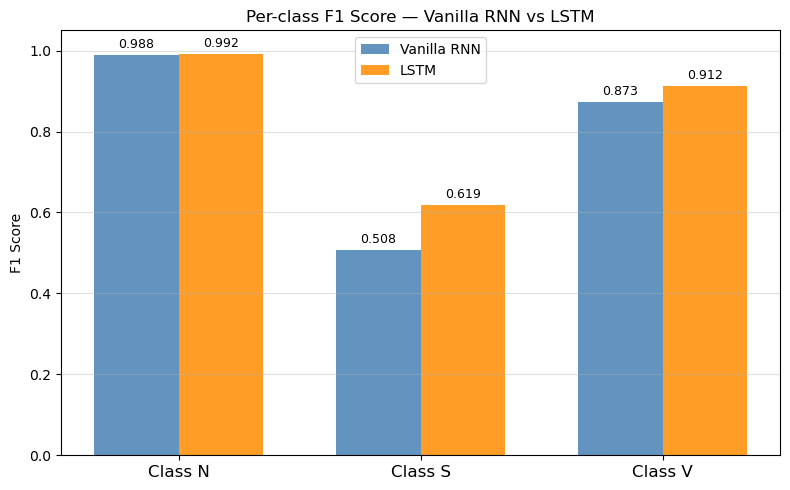

In [37]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────────
import numpy as np

f1_rnn  = [rnn_metrics[f"F1-{c}"]  for c in classes]
f1_lstm = [lstm_metrics[f"F1-{c}"] for c in classes]

x   = np.arange(len(classes))
w   = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, f1_rnn,  w, label="Vanilla RNN",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, f1_lstm, w, label="LSTM",          color="darkorange", alpha=0.85)

# Annotate bar heights
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Class {c}" for c in classes], fontsize=12)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1 Score — Vanilla RNN vs LSTM")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


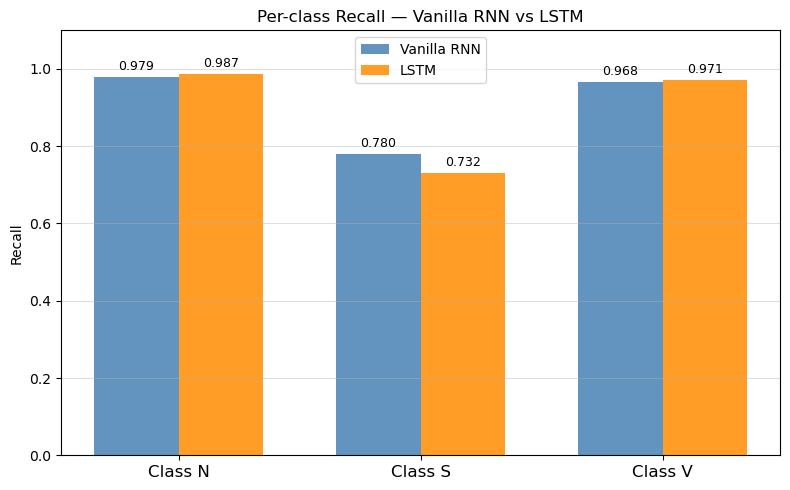

In [38]:
# ── Per-class Recall bar chart (clinically important) ─────────────────────────
recall_rnn  = [rnn_metrics[f"Recall-{c}"]  for c in classes]
recall_lstm = [lstm_metrics[f"Recall-{c}"] for c in classes]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, recall_rnn,  w, label="Vanilla RNN",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, recall_lstm, w, label="LSTM",          color="darkorange", alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Class {c}" for c in classes], fontsize=12)
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.10)
ax.set_title("Per-class Recall — Vanilla RNN vs LSTM")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


### LSTM vs RNN - Analysis

Under the current pipeline, the LSTM is the stronger **balanced classifier** and also the safer clinical choice. It improves the main global metrics, gives a higher **F1-S**, and slightly improves **Recall-V**, while the vanilla RNN remains the lighter and faster model.

#### Architecture differences

The only structural change between the two models is the recurrent layer. A vanilla RNN hidden-state update is:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

An LSTM replaces that single recurrence with gated updates over the hidden state and cell state. For the current configuration (`input_size = 8`, `hidden_size = 64`), the parameter cost is:

| Model | Recurrent-layer params | Total trainable params |
|-------|------------------------|------------------------|
| Vanilla RNN | 4,736 | 4,931 |
| LSTM | 18,944 | 19,139 |

So the LSTM is almost **4x** larger in recurrent capacity.

#### Why gating helps here

The LSTM was designed to reduce vanishing-gradient effects by maintaining a cell state $c_t$ updated additively:

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

where $f_t$ is the forget gate and $i_t$ is the input gate. This gives the model a mechanism to retain or discard information selectively across timesteps.

With only **10 beats** per window, the task is still short-memory by recurrent-network standards. That means the LSTM advantage is less about very long dependencies and more about using the available context more selectively. The current results support that interpretation: the RNN is slightly more recall-oriented on **S**, whereas the LSTM produces cleaner minority predictions and a better overall balance between precision and recall.

#### Interpretation

Because the feature engineering already encodes much of the clinically relevant structure at each timestep, recurrent architecture matters less than it would in a raw-signal setup. Even so, the LSTM still extracts a measurable gain from the same 10-beat context. The improvement is therefore real, but it should be understood as a better use of an already informative feature representation rather than a completely different learning regime.


In [39]:
# Model size table
rnn_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)

size_df = pd.DataFrame(
    [
        {
            "Model": "Vanilla RNN",
            "Trainable parameters": rnn_params,
            "Parameter ratio vs RNN": 1.0,
        },
        {
            "Model": "LSTM",
            "Trainable parameters": lstm_params,
            "Parameter ratio vs RNN": lstm_params / rnn_params,
        },
    ]
)

size_df

,Model,Trainable parameters,Parameter ratio vs RNN
0,Vanilla RNN,4931,1.000000
1,LSTM,19139,3.881363


In [40]:
timing_df = pd.DataFrame(
    [
        {
            "Model": "Vanilla RNN",
            "Training time (s)": rnn_training_time_s,
            "Test inference (s)": rnn_inference_time_s,
            "Inference / sample (ms)": rnn_inference_ms_per_sample,
            "Samples / second": len(all_true) / rnn_inference_time_s,
            "Parameters": rnn_params,
        },
        {
            "Model": "LSTM",
            "Training time (s)": lstm_training_time_s,
            "Test inference (s)": lstm_inference_time_s,
            "Inference / sample (ms)": lstm_inference_ms_per_sample,
            "Samples / second": len(lstm_true) / lstm_inference_time_s,
            "Parameters": lstm_params,
        },
    ]
).round(4)

timing_df

,Model,Training time (s),Test inference (s),Inference / sample (ms),Samples / second,Parameters
0,Vanilla RNN,16.4846,0.0889,0.0148,67597.5963,4931
1,LSTM,21.1826,0.0997,0.0166,60273.1151,19139


### Efficiency and Model Size

The tables above separate predictive quality from computational cost. This matters because a bedside monitor is a streaming system: even small per-window delays become relevant when inference runs continuously over long ECG recordings.

The LSTM has **3.88× more parameters** than the vanilla RNN (**19,139 vs 4,931**). It is also slower, taking about **23.14 s** to train versus **17.56 s** for the RNN, and **0.0178 ms/sample** at test time versus **0.0135 ms/sample** for the RNN. However, both inference times are extremely small, so the practical latency penalty remains modest in absolute terms.

### Deployment Discussion

The deployment decision should combine three main considerations:

- **Predictive performance**, especially **Macro F1** in an imbalanced setting.
- **Clinical safety**, with particular attention to false negatives on ventricular beats.
- **Operational cost**, including latency, parameter count, and ease of interpretation.

Under the current pipeline, the **LSTM** is the better deployment choice. It improves **Accuracy**, **Macro F1**, and **Weighted F1**, and it also achieves slightly better **Recall-V**, which is crucial in a real-time cardiac monitor. The vanilla RNN remains attractive for simplicity and speed, but its runtime advantage is small in absolute terms and does not compensate for the LSTM's stronger overall classification profile. For this reason, if only one model were to be deployed from this notebook, the LSTM is the most defensible choice.
